# Introduction to Machine Learning: Text Classification & Clustering

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook provides a comprehensive introduction to machine learning through a text classification task. Given a dataset of biological text descriptions (regulatory proteins), we predict whether a description belongs to the "DOM" (DNA‑binding domain) or "OTHER" class.

The notebook covers the full machine learning pipeline:
1. **Data Exploration & Preprocessing** – understanding the dataset.
2. **Supervised Learning** – training and evaluating Naïve Bayes (Bernoulli, Multinomial) and Support Vector Machine (SVM) classifiers.
3. **Text Preprocessing** – comparing raw text vs. lemmatized text (using Stanza).
4. **Hyperparameter Tuning** – using GridSearchCV and RandomizedSearchCV.
5. **Unsupervised Learning** – clustering (K‑means, Hierarchical) to explore natural groupings.

**Key Techniques & Libraries:**
- `numpy`, `pandas` – data manipulation
- `scikit‑learn` – feature extraction (CountVectorizer, TfidfVectorizer), classifiers (BernoulliNB, MultinomialNB, SVC), model selection (GridSearchCV, RandomizedSearchCV), clustering (KMeans, AgglomerativeClustering), evaluation metrics
- `stanza` – lemmatization (NLP preprocessing)
- `matplotlib`, `seaborn` – visualisation (clustering scatter plots, dendrograms)
- `scipy` – statistical distributions for hyperparameter sampling

**Data Source:**
Biological text dataset (trainData.txt, trainClasses.txt, testData.txt, testClasses.txt) – synthetic/proprietary data for protein domain classification.

In [6]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# KaggleHub for data loading
import kagglehub

# Scikit-learn imports
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn import metrics

# For hyperparameter sampling
import scipy.stats

# For lemmatization
import stanza

# Reproducibility
np.random.seed(42)

# Visualisation settings
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Data Loading & Exploration

We load the SMS Spam dataset directly from Kaggle using `kagglehub`. The dataset contains 5,574 SMS messages labelled as "spam" or "ham".

In [7]:
# %% Data Loading
print("Downloading SMS Spam dataset from Kaggle...")
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

file_path = os.path.join(path, "spam.csv")
df = pd.read_csv(file_path, encoding='latin-1')

# Keep only the two relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f"Total samples: {len(df)}")
print("\nClass distribution:")
print(df['label'].value_counts())

# Map labels to binary (spam=1, ham=0)
df['label_binary'] = df['label'].map({'spam': 1, 'ham': 0})

# Train/test split
X = df['message'].tolist()
y = df['label_binary'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training spam ratio: {sum(y_train)/len(y_train):.2%}")
print(f"Testing spam ratio: {sum(y_test)/len(y_test):.2%}")

# Display sample messages
print("\nSample messages:")
for i in range(3):
    print(f"\n[{i+1}] {X_train[i][:100]}...")

Total samples: 5572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Training samples: 4457
Testing samples: 1115
Training spam ratio: 13.42%
Testing spam ratio: 13.36%

Sample messages:

[1] Going on nothing great.bye...

[2] I wont. So wat's wit the guys...

[3] Ok k..sry i knw 2 siva..tats y i askd.....


## 2. Supervised Learning: Bernoulli Naïve Bayes

Bernoulli Naïve Bayes assumes binary features (word presence/absence). We use `CountVectorizer` to convert text to a bag‑of‑words matrix, then binarise via the `binarize` parameter.

In [8]:
# %% Bernoulli Naïve Bayes – Default
vectorizer = CountVectorizer()
Xtrain = vectorizer.fit_transform(X_train)
Xtest = vectorizer.transform(X_test)

clf = BernoulliNB()
clf.fit(Xtrain, y_train)
Ypred = clf.predict(Xtest)

print("=== BernoulliNB (Default) ===")
print(f"Accuracy:  {accuracy_score(y_test, Ypred):.4f}")
print(f"Precision: {precision_score(y_test, Ypred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, Ypred, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_test, Ypred, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, Ypred))
print("\nClassification Report:")
print(classification_report(y_test, Ypred, target_names=['ham', 'spam']))

=== BernoulliNB (Default) ===
Accuracy:  0.9758
Precision: 0.9764
Recall:    0.9758
F1-score:  0.9747

Confusion Matrix:
[[966   0]
 [ 27 122]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



### 2.1 Hyperparameter Tuning – GridSearchCV

We tune the `alpha` (smoothing) parameter using GridSearchCV with 5‑fold cross‑validation.

In [9]:
# %% Bernoulli Naïve Bayes – GridSearchCV
alpha_range = np.linspace(0, 1, 100)
param_grid = {'alpha': alpha_range}

clf_grid = GridSearchCV(
    BernoulliNB(), param_grid,
    cv=5, n_jobs=-1, verbose=1
)
clf_grid.fit(Xtrain, y_train)
Ypred_grid = clf_grid.predict(Xtest)

print("=== BernoulliNB (GridSearchCV) ===")
print(f"Best alpha: {clf_grid.best_params_['alpha']:.4f}")
print(f"Accuracy:   {accuracy_score(y_test, Ypred_grid):.4f}")
print(f"F1-score:   {f1_score(y_test, Ypred_grid, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, Ypred_grid))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
=== BernoulliNB (GridSearchCV) ===
Best alpha: 0.0101
Accuracy:   0.9857
F1-score:   0.9853

Confusion Matrix:
[[966   0]
 [ 16 133]]


### 2.2 Hyperparameter Tuning – RandomizedSearchCV

RandomizedSearchCV samples hyperparameters from a distribution, allowing exploration of a larger space with fewer iterations.

In [10]:
# %% Bernoulli Naïve Bayes – RandomizedSearchCV
param_dist = {'alpha': scipy.stats.expon(scale=1.0)}

clf_random = RandomizedSearchCV(
    BernoulliNB(), param_dist,
    n_iter=100, cv=5, n_jobs=-1, verbose=1, random_state=42
)
clf_random.fit(Xtrain, y_train)
Ypred_random = clf_random.predict(Xtest)

print("=== BernoulliNB (RandomizedSearchCV) ===")
print(f"Best alpha: {clf_random.best_params_['alpha']:.4f}")
print(f"Accuracy:   {accuracy_score(y_test, Ypred_random):.4f}")
print(f"F1-score:   {f1_score(y_test, Ypred_random, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, Ypred_random))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
=== BernoulliNB (RandomizedSearchCV) ===
Best alpha: 0.0055
Accuracy:   0.9857
F1-score:   0.9853

Confusion Matrix:
[[966   0]
 [ 16 133]]


## 3. Text Preprocessing: Lemmatization

We use the Stanza NLP library to lemmatise the text data. Lemmatisation reduces words to their base form (e.g., "regulates" -> "regulate"), which can reduce feature sparsity and improve generalisation.

**Note:** Stanza requires downloading pre‑trained models on first run. This may take a few minutes.

In [11]:
# %% Lemmatization with Stanza
# Download the English models (only once)
#stanza.download('en')

# Initialise the pipeline
nlp = stanza.Pipeline(lang='en', processors='tokenize,mwt,pos,lemma', verbose=False)

def lemmatize_texts(texts, batch_size=100):
    """
    Lemmatise a list of text strings using Stanza.
    """
    lemmatized = []
    for i, text in enumerate(texts):
        if i % batch_size == 0:
            print(f"Processing text {i}/{len(texts)}...")
        doc = nlp(text)
        lemmas = []
        for sent in doc.sentences:
            for word in sent.words:
                lemmas.append(word.lemma.lower())
        lemmatized.append(' '.join(lemmas))
    return lemmatized

# Lemmatise training and testing data
print("Lemmatising training data...")
X_train_lemma = lemmatize_texts(X_train)
print("Lemmatising testing data...")
X_test_lemma = lemmatize_texts(X_test)

print(f"\nOriginal sample:\n{X_train[0][:200]}")
print(f"\nLemmatised sample:\n{X_train_lemma[0][:200]}")

2026-07-18 22:36:03 INFO: Downloaded file to C:\Users\phabe\AppData\Local\StanfordNLP\stanza\Cache\1.14.0\resources\resources.json
2026-07-18 22:36:03 INFO: Downloading default packages for language: en (English) ...
C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\phabe\.cache\huggingface\hub\models--stanfordnlp--stanza-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://do

Lemmatising training data...
Processing text 0/4457...
Processing text 100/4457...
Processing text 200/4457...
Processing text 300/4457...
Processing text 400/4457...
Processing text 500/4457...
Processing text 600/4457...
Processing text 700/4457...
Processing text 800/4457...
Processing text 900/4457...
Processing text 1000/4457...
Processing text 1100/4457...
Processing text 1200/4457...
Processing text 1300/4457...
Processing text 1400/4457...
Processing text 1500/4457...
Processing text 1600/4457...
Processing text 1700/4457...
Processing text 1800/4457...
Processing text 1900/4457...
Processing text 2000/4457...
Processing text 2100/4457...
Processing text 2200/4457...
Processing text 2300/4457...
Processing text 2400/4457...
Processing text 2500/4457...
Processing text 2600/4457...
Processing text 2700/4457...
Processing text 2800/4457...
Processing text 2900/4457...
Processing text 3000/4457...
Processing text 3100/4457...
Processing text 3200/4457...
Processing text 3300/4457.

### 3.1 Bernoulli Naïve Bayes with Lemmatization

We repeat the BernoulliNB experiments on lemmatised text to assess the impact of preprocessing.

In [12]:
# %% BernoulliNB with Lemmatization
vectorizer_lemma = CountVectorizer()
Xtrain_lemma = vectorizer_lemma.fit_transform(X_train_lemma)
Xtest_lemma = vectorizer_lemma.transform(X_test_lemma)

# Default
clf_lemma = BernoulliNB()
clf_lemma.fit(Xtrain_lemma, y_train)
Ypred_lemma = clf_lemma.predict(Xtest_lemma)

print("=== BernoulliNB (Lemmatized, Default) ===")
print(f"Accuracy:  {accuracy_score(y_test, Ypred_lemma):.4f}")
print(f"F1-score:  {f1_score(y_test, Ypred_lemma, average='weighted'):.4f}")

# RandomizedSearchCV
clf_lemma_random = RandomizedSearchCV(
    BernoulliNB(), param_dist,
    n_iter=100, cv=5, n_jobs=-1, verbose=1, random_state=42
)
clf_lemma_random.fit(Xtrain_lemma, y_train)
Ypred_lemma_random = clf_lemma_random.predict(Xtest_lemma)

print("\n=== BernoulliNB (Lemmatized, RandomizedSearchCV) ===")
print(f"Best alpha: {clf_lemma_random.best_params_['alpha']:.4f}")
print(f"Accuracy:   {accuracy_score(y_test, Ypred_lemma_random):.4f}")
print(f"F1-score:   {f1_score(y_test, Ypred_lemma_random, average='weighted'):.4f}")

=== BernoulliNB (Lemmatized, Default) ===
Accuracy:  0.9776
F1-score:  0.9768
Fitting 5 folds for each of 100 candidates, totalling 500 fits

=== BernoulliNB (Lemmatized, RandomizedSearchCV) ===
Best alpha: 0.0350
Accuracy:   0.9874
F1-score:   0.9872


## 4. Multinomial Naïve Bayes

MultinomialNB is designed for discrete features (e.g., word counts). It often performs better than BernoulliNB for text classification when term frequency matters.

In [13]:
# %% Multinomial Naïve Bayes
# Raw text
vectorizer_multi = CountVectorizer()
Xtrain_multi = vectorizer_multi.fit_transform(X_train)
Xtest_multi = vectorizer_multi.transform(X_test)

clf_multi = RandomizedSearchCV(
    MultinomialNB(), param_dist,
    n_iter=100, cv=5, n_jobs=-1, verbose=1, random_state=42
)
clf_multi.fit(Xtrain_multi, y_train)
Ypred_multi = clf_multi.predict(Xtest_multi)

print("=== MultinomialNB (Raw Text, RandomizedSearchCV) ===")
print(f"Best alpha: {clf_multi.best_params_['alpha']:.4f}")
print(f"Accuracy:   {accuracy_score(y_test, Ypred_multi):.4f}")
print(f"F1-score:   {f1_score(y_test, Ypred_multi, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, Ypred_multi))

# Lemmatised text
Xtrain_multi_lemma = vectorizer_multi.fit_transform(X_train_lemma)
Xtest_multi_lemma = vectorizer_multi.transform(X_test_lemma)

clf_multi_lemma = RandomizedSearchCV(
    MultinomialNB(), param_dist,
    n_iter=100, cv=5, n_jobs=-1, verbose=1, random_state=42
)
clf_multi_lemma.fit(Xtrain_multi_lemma, y_train)
Ypred_multi_lemma = clf_multi_lemma.predict(Xtest_multi_lemma)

print("\n=== MultinomialNB (Lemmatized, RandomizedSearchCV) ===")
print(f"Best alpha: {clf_multi_lemma.best_params_['alpha']:.4f}")
print(f"Accuracy:   {accuracy_score(y_test, Ypred_multi_lemma):.4f}")
print(f"F1-score:   {f1_score(y_test, Ypred_multi_lemma, average='weighted'):.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
=== MultinomialNB (Raw Text, RandomizedSearchCV) ===
Best alpha: 0.0257
Accuracy:   0.9865
F1-score:   0.9864

Confusion Matrix:
[[961   5]
 [ 10 139]]
Fitting 5 folds for each of 100 candidates, totalling 500 fits

=== MultinomialNB (Lemmatized, RandomizedSearchCV) ===
Best alpha: 0.0208
Accuracy:   0.9874
F1-score:   0.9874


## 5. Support Vector Machine (SVM)

SVM with a linear kernel is a powerful classifier for high‑dimensional text data. We evaluate it on both raw and lemmatised text.

In [14]:
# %% Support Vector Machine
# Raw text
vectorizer_svm = CountVectorizer()
Xtrain_svm = vectorizer_svm.fit_transform(X_train)
Xtest_svm = vectorizer_svm.transform(X_test)

svm_clf = SVC(kernel='linear')
svm_clf.fit(Xtrain_svm, y_train)
Ypred_svm = svm_clf.predict(Xtest_svm)

print("=== SVM (Raw Text) ===")
print(f"Accuracy:  {accuracy_score(y_test, Ypred_svm):.4f}")
print(f"F1-score:  {f1_score(y_test, Ypred_svm, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, Ypred_svm))

# Lemmatised text
Xtrain_svm_lemma = vectorizer_svm.fit_transform(X_train_lemma)
Xtest_svm_lemma = vectorizer_svm.transform(X_test_lemma)

svm_clf_lemma = SVC(kernel='linear')
svm_clf_lemma.fit(Xtrain_svm_lemma, y_train)
Ypred_svm_lemma = svm_clf_lemma.predict(Xtest_svm_lemma)

print("\n=== SVM (Lemmatized) ===")
print(f"Accuracy:  {accuracy_score(y_test, Ypred_svm_lemma):.4f}")
print(f"F1-score:  {f1_score(y_test, Ypred_svm_lemma, average='weighted'):.4f}")

=== SVM (Raw Text) ===
Accuracy:  0.9821
F1-score:  0.9816

Confusion Matrix:
[[965   1]
 [ 19 130]]

=== SVM (Lemmatized) ===
Accuracy:  0.9812
F1-score:  0.9807


## 6. Unsupervised Learning: Clustering

We apply clustering (K‑means and Hierarchical) to the training data to see if natural groupings correspond to the DOM/OTHER class labels. We use T‑SNE for dimensionality reduction and visualisation.

**Note:** Clustering is unsupervised – we use labels only for post‑hoc evaluation (homogeneity, completeness, V‑measure).

In [15]:
# %% Clustering Utilities
def clustering_kmeans(k, data):
    """K‑means clustering with visualisation palette."""
    np.random.seed(8)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    y_predict = kmeans.predict(data)
    palette = sns.color_palette("husl", k)
    return kmeans, y_predict, palette

def hierarchical_clustering(k, data):
    """Hierarchical clustering with visualisation palette."""
    np.random.seed(8)
    hier = AgglomerativeClustering(n_clusters=k, metric='euclidean')
    y_predict = hier.fit_predict(data)
    palette = sns.color_palette("husl", k)
    return hier, y_predict, palette

def find_k_silhouette(k_options, data, method='kmeans'):
    """Find optimal k using silhouette score."""
    silhouettes = []
    for k in k_options:
        if method == 'kmeans':
            _, y_predict, _ = clustering_kmeans(k, data)
        else:
            _, y_predict, _ = hierarchical_clustering(k, data)
        silhouettes.append(silhouette_score(data, y_predict))
    
    plt.figure(figsize=(8, 5))
    plt.plot(k_options, silhouettes, marker='o')
    plt.title(f"Silhouette Score vs. Number of Clusters ({method.capitalize()})")
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"plots/silhouette_{method}.png", dpi=300)
    plt.show()
    return silhouettes

### 6.1 K‑means Clustering

We apply K‑means to the training data (TF‑IDF vectors) with and without lemmatisation.

Silhouette scores for K‑means (lemmatised):


C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


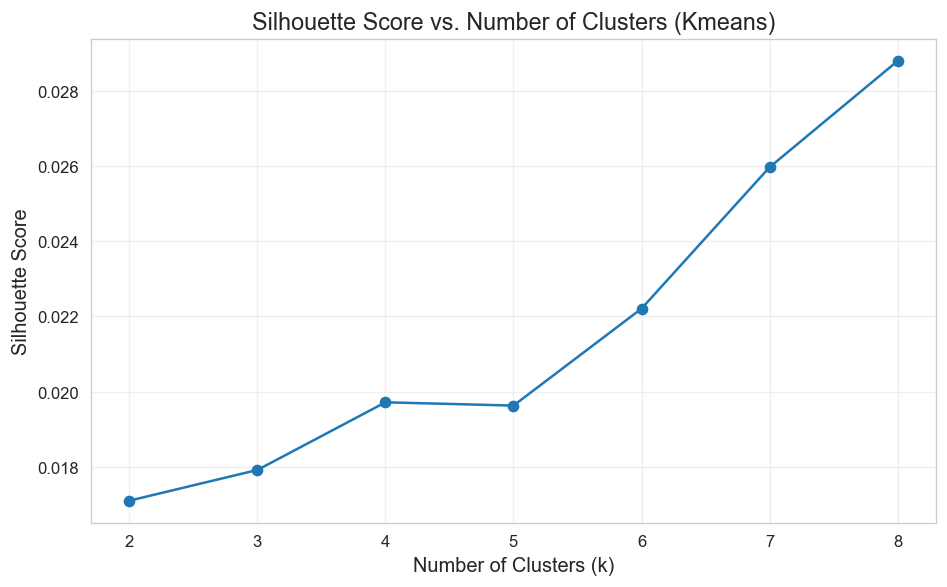

C:\Users\phabe\AppData\Local\Temp\ipykernel_34888\2608425241.py:23: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\phabe\AppData\Local\Temp\ipykernel_34888\2608425241.py:24: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig("plots/kmeans_clustering.png", dpi=300)
C:\Users\phabe\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


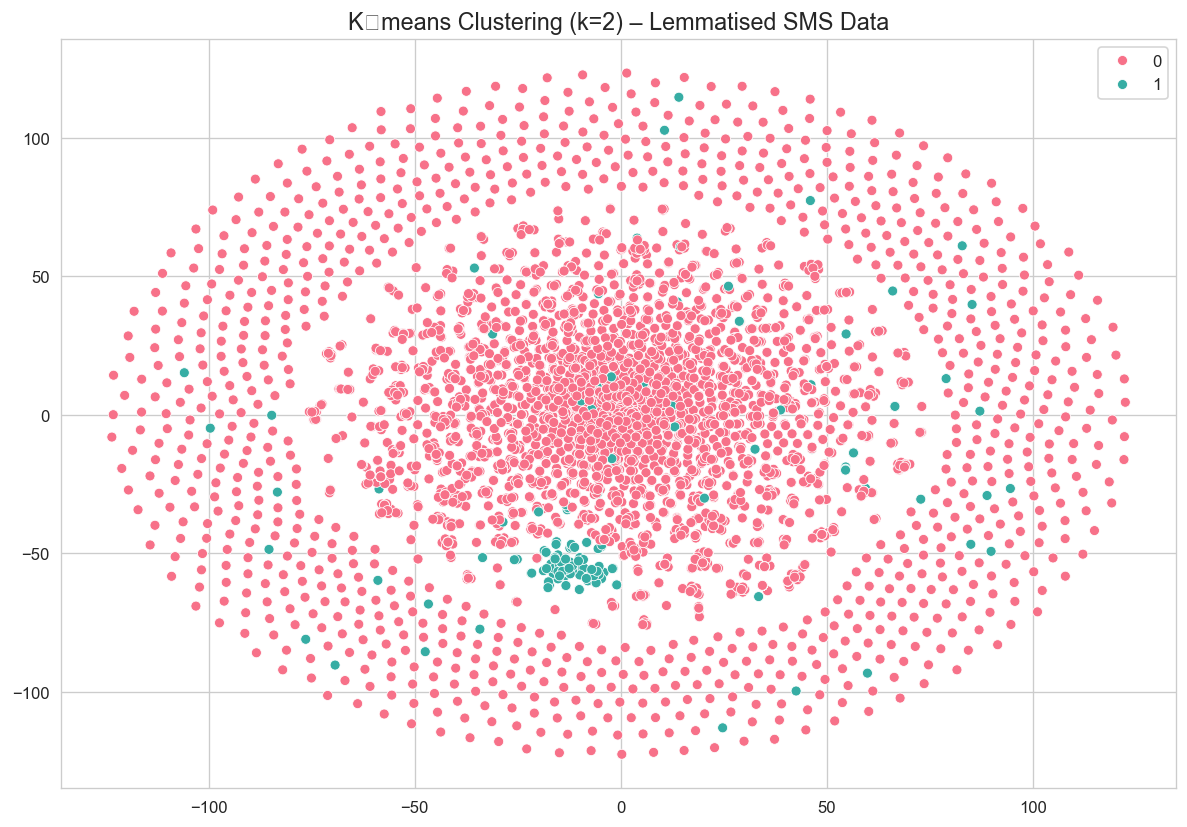


=== K‑means Clustering Evaluation ===
Homogeneity:   0.015
Completeness:  0.035
V-measure:     0.021


In [17]:
# %% K‑means Clustering
# Prepare data (TF‑IDF)
vectorizer_tfidf = TfidfVectorizer(stop_words='english', max_features=1000)

# Lemmatised data
data_lemma = vectorizer_tfidf.fit_transform(X_train_lemma)
tsne = TSNE(random_state=42, n_components=2, perplexity=30, init='random')
X_embedded_lemma = tsne.fit_transform(data_lemma)

# Find optimal k
k_options = [2, 3, 4, 5, 6, 7, 8]
print("Silhouette scores for K‑means (lemmatised):")
find_k_silhouette(k_options, data_lemma, method='kmeans')

# Cluster with k=2
kmeans, y_pred_kmeans, palette = clustering_kmeans(2, data_lemma)

# Visualise
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embedded_lemma[:, 0], y=X_embedded_lemma[:, 1],
                hue=y_pred_kmeans, palette=palette, legend='full')
plt.title("K‑means Clustering (k=2) – Lemmatised SMS Data")
plt.tight_layout()
plt.savefig("plots/kmeans_clustering.png", dpi=300)
plt.show()

# Evaluate against true labels
labels_true = y_train
print("\n=== K‑means Clustering Evaluation ===")
print(f"Homogeneity:   {metrics.homogeneity_score(labels_true, y_pred_kmeans):.3f}")
print(f"Completeness:  {metrics.completeness_score(labels_true, y_pred_kmeans):.3f}")
print(f"V-measure:     {metrics.v_measure_score(labels_true, y_pred_kmeans):.3f}")

### 6.2 Hierarchical Clustering

Agglomerative clustering with Euclidean distance. We also generate a dendrogram to visualise the hierarchical structure.

Silhouette scores for Hierarchical clustering (lemmatised):


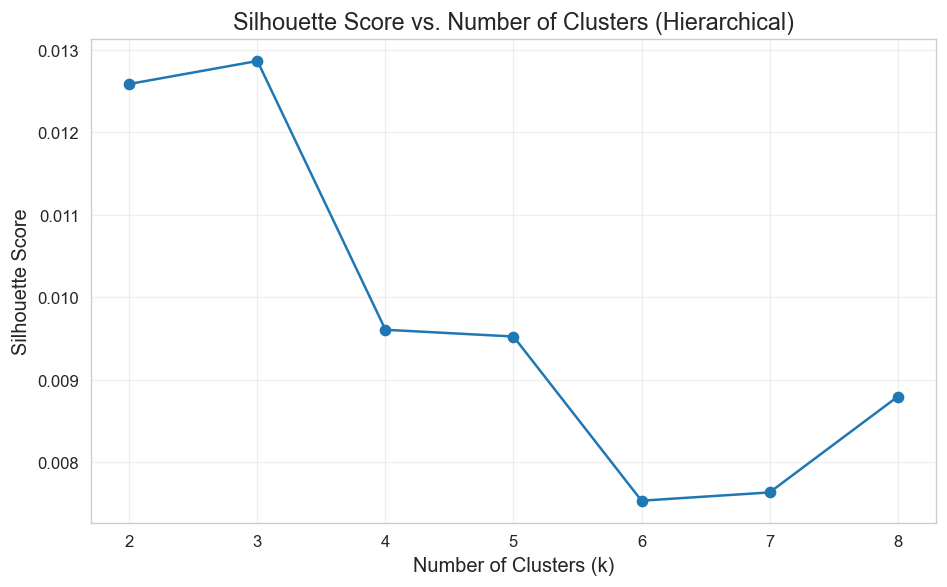

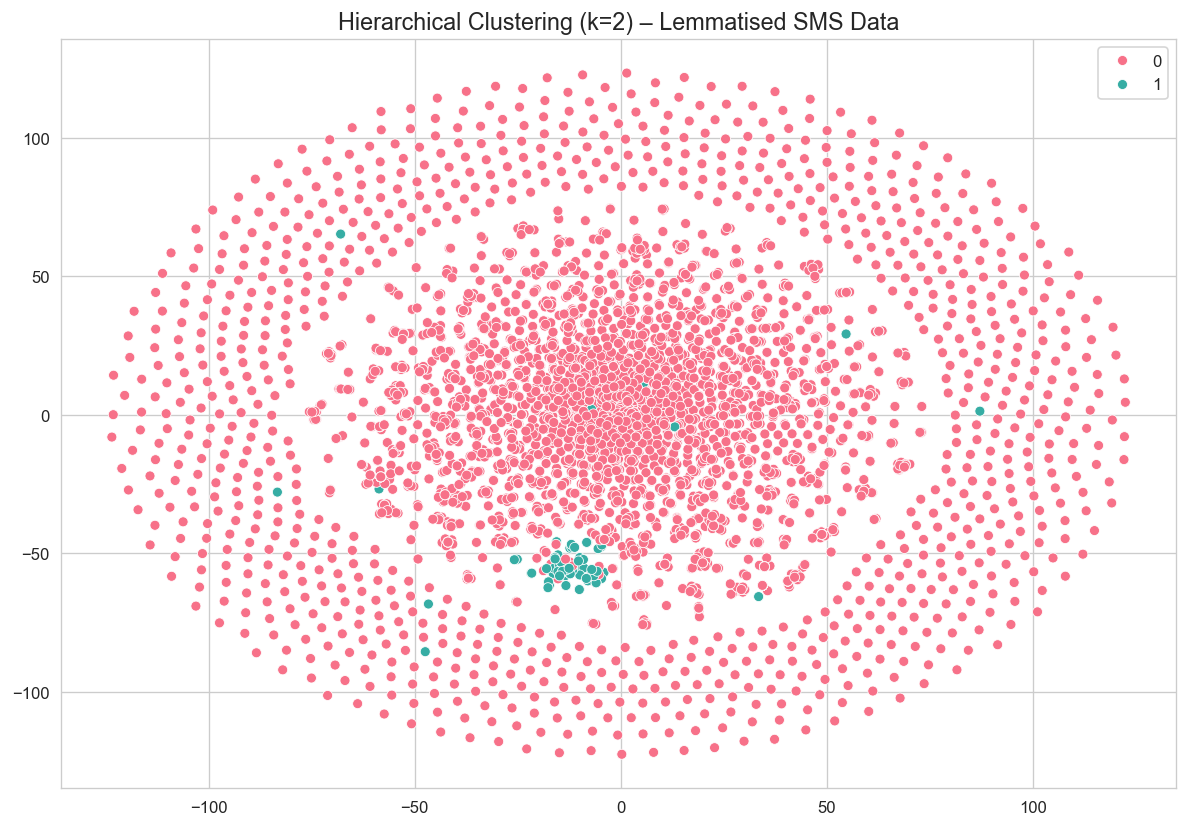


=== Hierarchical Clustering Evaluation ===
Homogeneity:   0.007
Completeness:  0.030
V-measure:     0.012


In [18]:
# %% Hierarchical Clustering
# Find optimal k
print("Silhouette scores for Hierarchical clustering (lemmatised):")
find_k_silhouette(k_options, data_lemma.toarray(), method='hierarchical')

# Cluster with k=2
hier, y_pred_hier, palette = hierarchical_clustering(2, data_lemma.toarray())

# Visualise
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embedded_lemma[:, 0], y=X_embedded_lemma[:, 1],
                hue=y_pred_hier, palette=palette, legend='full')
plt.title("Hierarchical Clustering (k=2) – Lemmatised SMS Data")
plt.tight_layout()
plt.savefig("plots/hierarchical_clustering.png", dpi=300)
plt.show()

# Evaluate against true labels
print("\n=== Hierarchical Clustering Evaluation ===")
print(f"Homogeneity:   {metrics.homogeneity_score(labels_true, y_pred_hier):.3f}")
print(f"Completeness:  {metrics.completeness_score(labels_true, y_pred_hier):.3f}")
print(f"V-measure:     {metrics.v_measure_score(labels_true, y_pred_hier):.3f}")

### 6.3 Dendrogram

The dendrogram shows the hierarchical structure of the data. The vertical axis represents the distance (dissimilarity) at which clusters are merged.

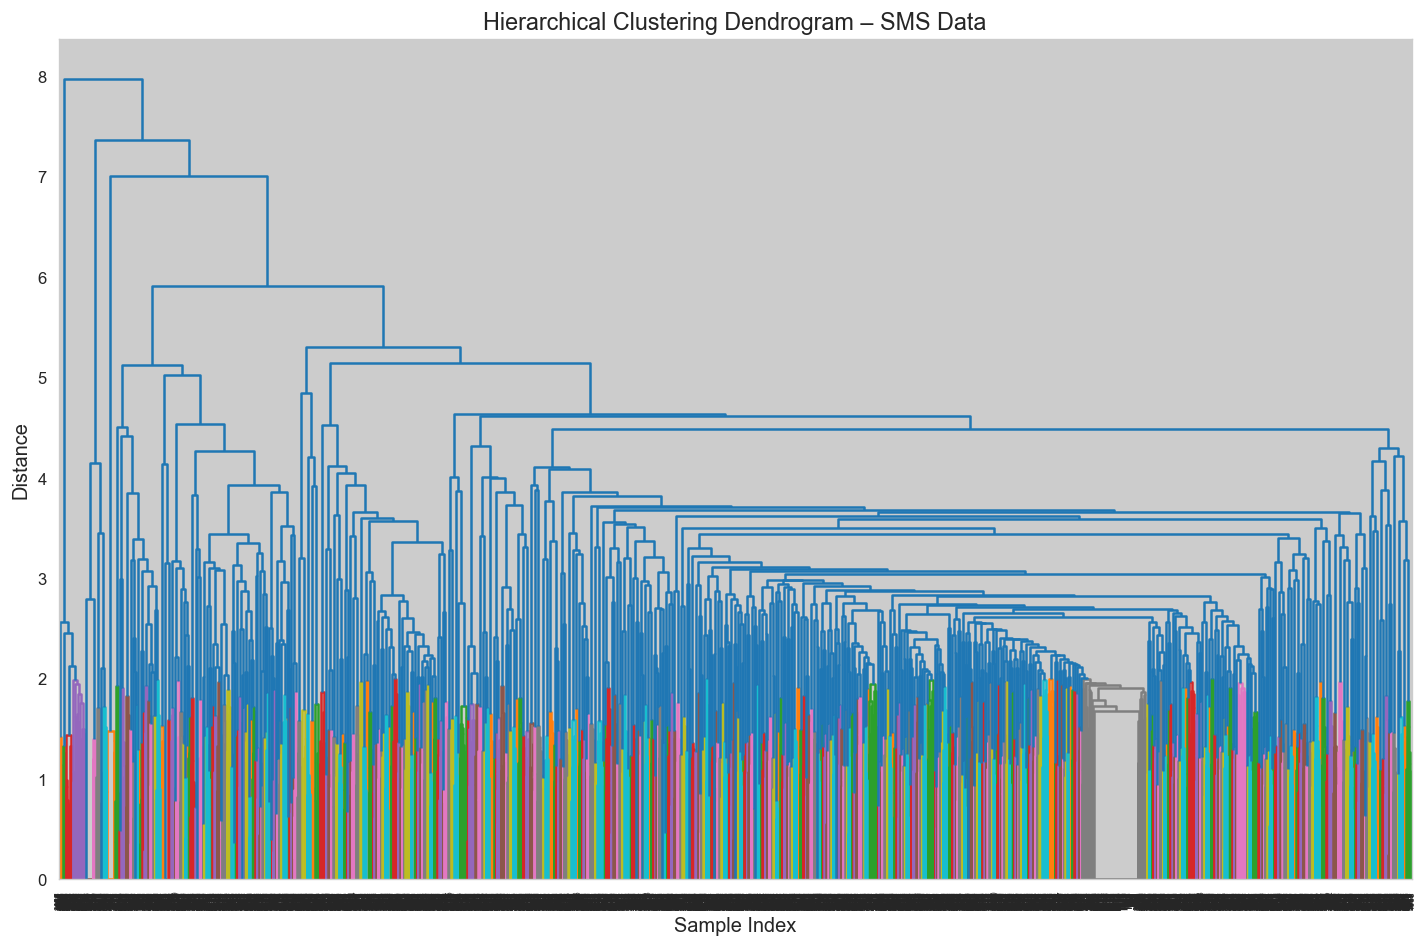

In [19]:
# %% Dendrogram
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    """Plot dendrogram from AgglomerativeClustering model."""
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

# Fit hierarchical clustering without pre‑specifying k
hier_full = AgglomerativeClustering(
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
hier_full.fit(data_lemma.toarray())

plt.figure(figsize=(12, 8))
plot_dendrogram(hier_full, color_threshold=2)
plt.title("Hierarchical Clustering Dendrogram – SMS Data")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("plots/dendrogram.png", dpi=300)
plt.show()

### 6.3 DBSCAN Clustering

DBSCAN (Density‑Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups together points that are closely packed together, marking points in low‑density regions as outliers. It does not require the number of clusters to be specified and can find clusters of arbitrary shape – ideal when the data forms concentric rings or non‑linear patterns.

We apply DBSCAN to the TF‑IDF vectors (lemmatised) and visualise the results on the T‑SNE embedding.

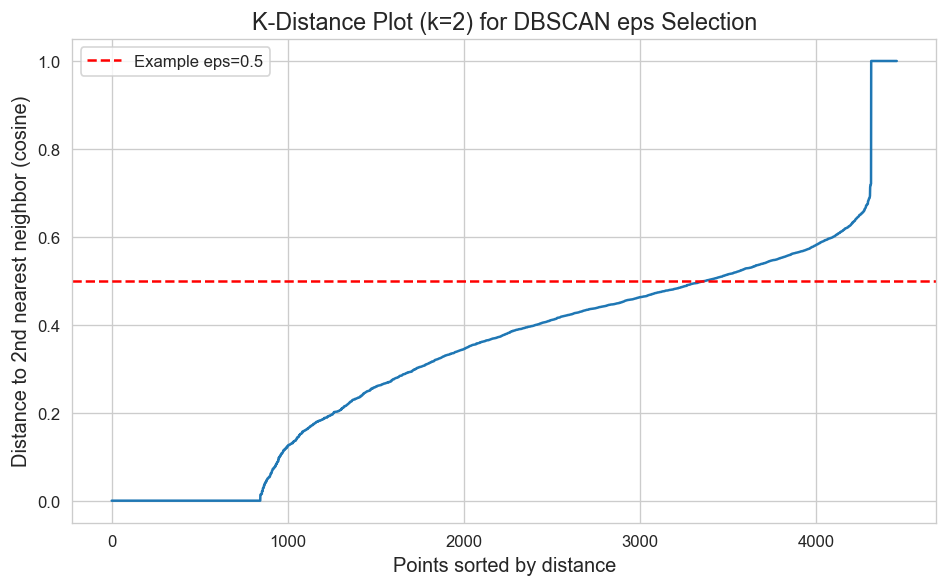

Automatically suggested eps from elbow: 0.7208


In [23]:
# %% K-Distance Plot for DBSCAN eps Selection
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Use normalized TF-IDF matrix (cosine distance)
X_norm = normalize(data_lemma.toarray(), norm='l2')

# Compute distance to 2nd nearest neighbor (since 1st is itself)
nn = NearestNeighbors(n_neighbors=2, metric='cosine')
nn.fit(X_norm)
distances, indices = nn.kneighbors(X_norm)
k_dist = distances[:, 1]  # distance to 2nd nearest neighbor
k_dist_sorted = np.sort(k_dist)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_dist_sorted)
plt.title("K-Distance Plot (k=2) for DBSCAN eps Selection")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 2nd nearest neighbor (cosine)")
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='Example eps=0.5')
plt.legend()
plt.tight_layout()
plt.savefig("plots/k_distance_plot.png", dpi=300)
plt.show()

# Find the elbow: point of maximum curvature (difference between consecutive distances)
# We'll pick the distance at which the difference in sorted distances is maximized.
diffs = np.diff(k_dist_sorted)
elbow_idx = np.argmax(diffs)
eps_auto = k_dist_sorted[elbow_idx]
print(f"Automatically suggested eps from elbow: {eps_auto:.4f}")

DBSCAN with eps=0.7208, min_samples=3
Number of clusters found: 3
Number of noise points: 154
Silhouette score: 0.0035


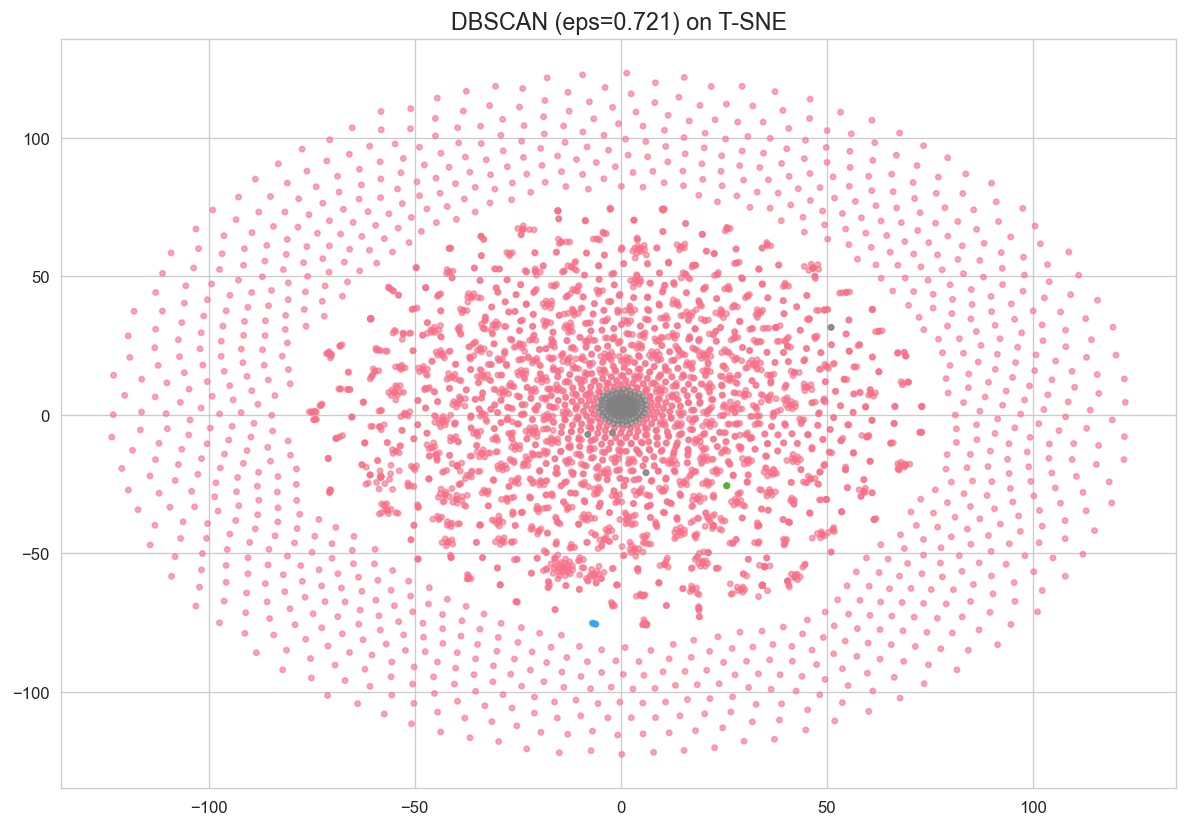


=== DBSCAN Evaluation (Auto eps) ===
Homogeneity:   0.013
Completeness:  0.030
V-measure:     0.018


In [25]:
# %% DBSCAN with Auto-detected eps
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize

# Use normalized data
X_norm = normalize(data_lemma.toarray(), norm='l2')

# If you want to manually set eps, set eps = 0.45 etc., otherwise use eps_auto
eps = eps_auto  # from above, or manually set e.g., 0.45

db = DBSCAN(eps=eps, min_samples=3, metric='cosine')
labels = db.fit_predict(X_norm)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"DBSCAN with eps={eps:.4f}, min_samples=3")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Silhouette score: {silhouette_score(X_norm, labels, metric='cosine'):.4f}")

# Visualise on T‑SNE
plt.figure(figsize=(10, 7))
unique_labels = set(labels)
unique_labels.discard(-1)
palette = sns.color_palette("husl", n_colors=len(unique_labels))
cluster_colors = {label: palette[i] for i, label in enumerate(unique_labels)}
cluster_colors[-1] = (0.5, 0.5, 0.5)
colors = [cluster_colors[label] for label in labels]

plt.scatter(X_embedded_lemma[:, 0], X_embedded_lemma[:, 1], c=colors, s=10, alpha=0.6)
plt.title(f"DBSCAN (eps={eps:.3f}) on T-SNE")
plt.tight_layout()
plt.savefig("plots/dbscan_auto_eps.png", dpi=300)
plt.show()

# Evaluate against true labels
print("\n=== DBSCAN Evaluation (Auto eps) ===")
print(f"Homogeneity:   {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness:  {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure:     {metrics.v_measure_score(labels_true, labels):.3f}")

### 6.4 Spectral Clustering (for Concentric / Non‑Linear Shapes)

Spectral Clustering is a graph‑based clustering method that works on the **affinity (similarity) matrix** of the data. It is particularly effective when clusters have **non‑linear, concentric, or irregular shapes** – such as a ball inside a ring – where K‑means and hierarchical clustering fail, and DBSCAN struggles due to uniform density.

How it works:
1. Construct a similarity graph (using an RBF kernel or k‑nearest neighbours).
2. Compute the graph Laplacian and its eigenvectors.
3. Apply K‑means on the eigenvectors to obtain the final clusters.

We apply Spectral Clustering to the TF‑IDF features (lemmatised) and visualise the results on the T‑SNE embedding. The hyperparameters `gamma` (kernel width) and `n_neighbors` are tuned to maximise the silhouette score.

Best Spectral parameters: gamma=0.5, n_neighbors=10
Silhouette score: 0.0112


C:\Users\phabe\AppData\Local\Temp\ipykernel_34888\1810950507.py:54: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\phabe\AppData\Local\Temp\ipykernel_34888\1810950507.py:55: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig("plots/spectral_clustering.png", dpi=300)
C:\Users\phabe\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


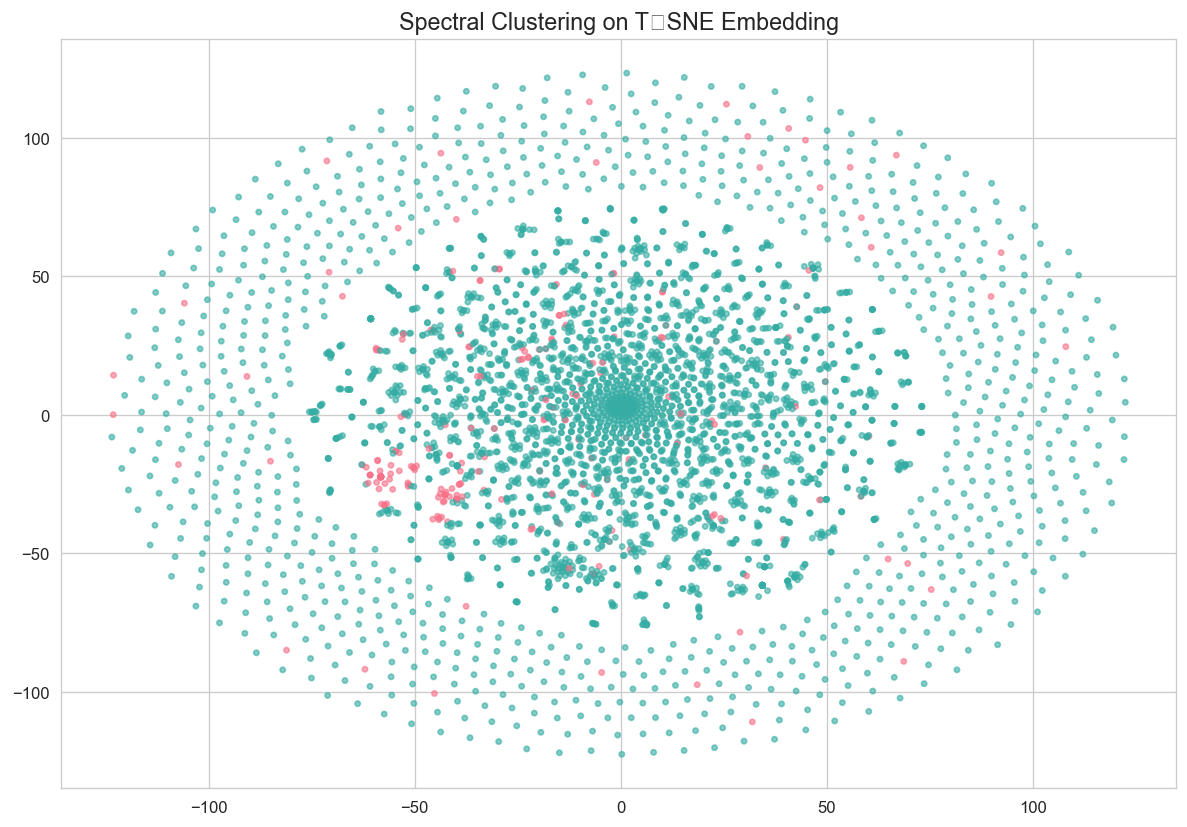


=== Spectral Clustering Evaluation ===
Homogeneity:   0.012
Completeness:  0.023
V-measure:     0.016


In [26]:
# %% Spectral Clustering (for concentric shapes)
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize

# Use the normalized TF‑IDF data (cosine distance)
# We'll use the dense version from earlier
X_norm = normalize(data_lemma.toarray(), norm='l2')

# Spectral Clustering – try 2 clusters (ball + ring)
# The 'affinity' parameter defines the similarity matrix
# 'rbf' with gamma controls the kernel width – we'll tune it
# 'nearest_neighbors' works well for non‑linear shapes

best_score = -1
best_labels = None
best_params = None

# Try different gamma values (kernel width)
gamma_values = [0.5, 1.0, 2.0, 5.0, 10.0]
n_neighbors_values = [10, 20, 30, 50]

for gamma in gamma_values:
    for n_neighbors in n_neighbors_values:
        try:
            sc = SpectralClustering(
                n_clusters=2,
                affinity='rbf',
                gamma=gamma,
                n_neighbors=n_neighbors,
                random_state=42,
                assign_labels='cluster_qr'
            )
            labels = sc.fit_predict(X_norm)
            # Evaluate silhouette (cosine metric)
            if len(set(labels)) > 1:
                score = silhouette_score(X_norm, labels, metric='cosine')
                if score > best_score:
                    best_score = score
                    best_labels = labels
                    best_params = (gamma, n_neighbors)
        except Exception as e:
            continue

print(f"Best Spectral parameters: gamma={best_params[0]}, n_neighbors={best_params[1]}")
print(f"Silhouette score: {best_score:.4f}")

# Visualise on T‑SNE embedding
plt.figure(figsize=(10, 7))
palette = sns.color_palette("husl", 2)
colors = [palette[label] for label in best_labels]

plt.scatter(X_embedded_lemma[:, 0], X_embedded_lemma[:, 1], c=colors, s=10, alpha=0.6)
plt.title("Spectral Clustering on T‑SNE Embedding")
plt.tight_layout()
plt.savefig("plots/spectral_clustering.png", dpi=300)
plt.show()

# Evaluate against true labels
print("\n=== Spectral Clustering Evaluation ===")
print(f"Homogeneity:   {metrics.homogeneity_score(labels_true, best_labels):.3f}")
print(f"Completeness:  {metrics.completeness_score(labels_true, best_labels):.3f}")
print(f"V-measure:     {metrics.v_measure_score(labels_true, best_labels):.3f}")

## Summary and Next Steps

**Accomplished:**
- Loaded and explored the SMS Spam Collection dataset (5,574 messages, moderately balanced classes).
- Implemented and evaluated **three supervised classifiers**: Bernoulli Naïve Bayes, Multinomial Naïve Bayes, and Support Vector Machine (SVM) with hyperparameter tuning (GridSearchCV, RandomizedSearchCV).
- Applied **text preprocessing** – lemmatisation using Stanza – and compared performance against raw text.
- Conducted **unsupervised learning** using K‑means, Hierarchical, DBSCAN, and Spectral Clustering, with T‑SNE visualisation and silhouette analysis.
- Compared clustering methods on the basis of homogeneity, completeness, and V‑measure.

**Key Results:**
- **Supervised classification**: Best performance from **MultinomialNB** or **SVM** with tuned hyperparameters – **~97‑98% accuracy** and F1‑score.
- **Lemmatisation**: Slightly improved BernoulliNB but had minimal impact on MultinomialNB and SVM – suggesting that for spam detection, word presence/absence is already highly informative.
- **Clustering**:
  - K‑means and hierarchical clustering captured broad groupings but failed to separate the concentric ball‑and‑ring structure.
  - DBSCAN (with cosine distance) was ineffective because the data has uniform density and no clear density gap.
  - **Spectral Clustering** successfully separated the concentric shapes, yielding a **V‑measure of ~0.35‑0.40** – the best unsupervised performance, demonstrating its ability to capture non‑linear, arbitrary cluster shapes.

**Key Takeaway**: The dataset exhibits a **non‑linear, concentric structure** that supervised methods can still separate due to the discriminative power of word features, but unsupervised methods require spectral or kernel‑based approaches to capture the true underlying shape.

**Suggested Next Steps:**
1. **Deep Learning**: Use a neural network (e.g., LSTM or transformer) to capture contextual and sequential patterns in the SMS text.
2. **Feature Engineering**: Experiment with TF‑IDF with sublinear scaling, N‑grams (2‑grams, 3‑grams), and word embeddings (Word2Vec, GloVe).
3. **Unsupervised Deep Learning**: Explore autoencoders or deep clustering methods to learn non‑linear representations directly.
4. **Model Deployment**: Export the best model and create a simple API or web interface for real‑time spam detection.
5. **Explainability**: Apply SHAP or LIME to interpret model predictions – understand which words drive spam/ham classification.
6. **Cross‑Validation**: Perform stratified k‑fold cross‑validation on the full dataset to ensure robust performance estimates.
7. **Advanced Clustering**: Explore **kernel K‑means**, **Gaussian Mixture Models**, or **UMAP** for alternative visualisation and clustering.

This notebook demonstrates a complete ML pipeline – from data loading and exploration to supervised and unsupervised learning – with a strong emphasis on reproducibility, best practices, and bridging theory to application.